In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

### Chargement du dataset fashion

In [2]:
# retroune 2 tuples: (image_train, label_train) et (image_test, label_test)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
               'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine']

print(f"Train set : {X_train.shape}")
print(f"Test set : {X_test.shape}")

Train set : (60000, 28, 28)
Test set : (10000, 28, 28)


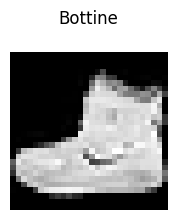

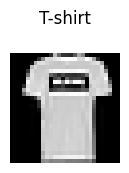

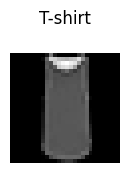

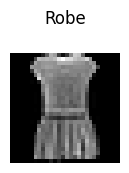

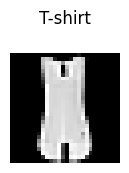

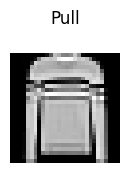

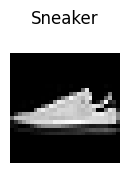

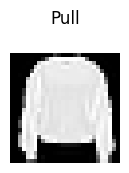

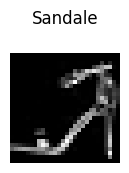

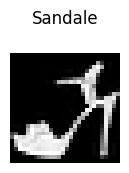

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"{class_names[y_train[i]]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### PREPROCESSING

In [4]:
# 1. Normalisation: division par 255 pour que les valeurs soient entre 0 et 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# applatissement: (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train_norm.reshape(-1, 28*28)
X_test_flat = X_test_norm.reshape(-1, 28*28)

print(f"Train set : {X_train_flat.shape}")
print(f"Test set : {X_test_flat.shape}")

# 2. Encodage des labels: one-hot encoding
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print(y_train_onehot[0])

Train set : (60000, 784)
Test set : (10000, 784)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


### Création du modèle

- Total params: 109 386 = (784 * 128 + 128) + (128 * 64 + 64) + (64 * 10 + 10)
- couche 1: 100 480 (poids + biais)

In [5]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), name="hidden_1"),
    layers.Dense(64, activation='relu', name="hidden_2"),
    layers.Dense(10, activation='softmax', name="output")
], name="MLP_Fashion_MNIST")

model.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_Fashion_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Configuration des parametres d'entrainement

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Entrainement du modele

In [7]:
history = model.fit(
    X_train_flat, y_train_onehot,
    epochs=10, # lance l'entrainement 10 fois
    batch_size=128, # traite 128 exemples à la fois avant de mettre à jour les poids
    validation_split=0.1, # utilise 10% du train set pour la validation
    verbose=1 # affiche les progrès de l'entrainement
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8071 - loss: 0.5511 - val_accuracy: 0.8450 - val_loss: 0.4231
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8592 - loss: 0.3969 - val_accuracy: 0.8608 - val_loss: 0.3877
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8738 - loss: 0.3480 - val_accuracy: 0.8695 - val_loss: 0.3544
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8828 - loss: 0.3237 - val_accuracy: 0.8710 - val_loss: 0.3461
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8879 - loss: 0.3060 - val_accuracy: 0.8817 - val_loss: 0.3300
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8929 - loss: 0.2898 - val_accuracy: 0.8777 - val_loss: 0.3311
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8986 - loss: 0.2743 - val_accuracy: 0.8828 - val_loss: 0.3127
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9028 - loss: 0.2627 - val_accuracy: 0.

### Graphique accuracy et loss

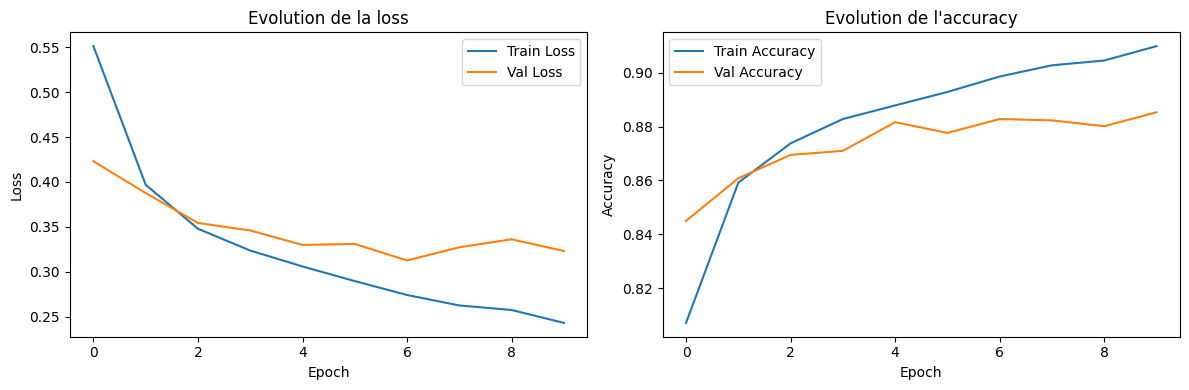

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss au cours des epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title("Evolution de la loss")
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy au cours des epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title("Evolution de l'accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# evaluer sur le test set
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_onehot, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3417, Test Accuracy: 0.8805


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


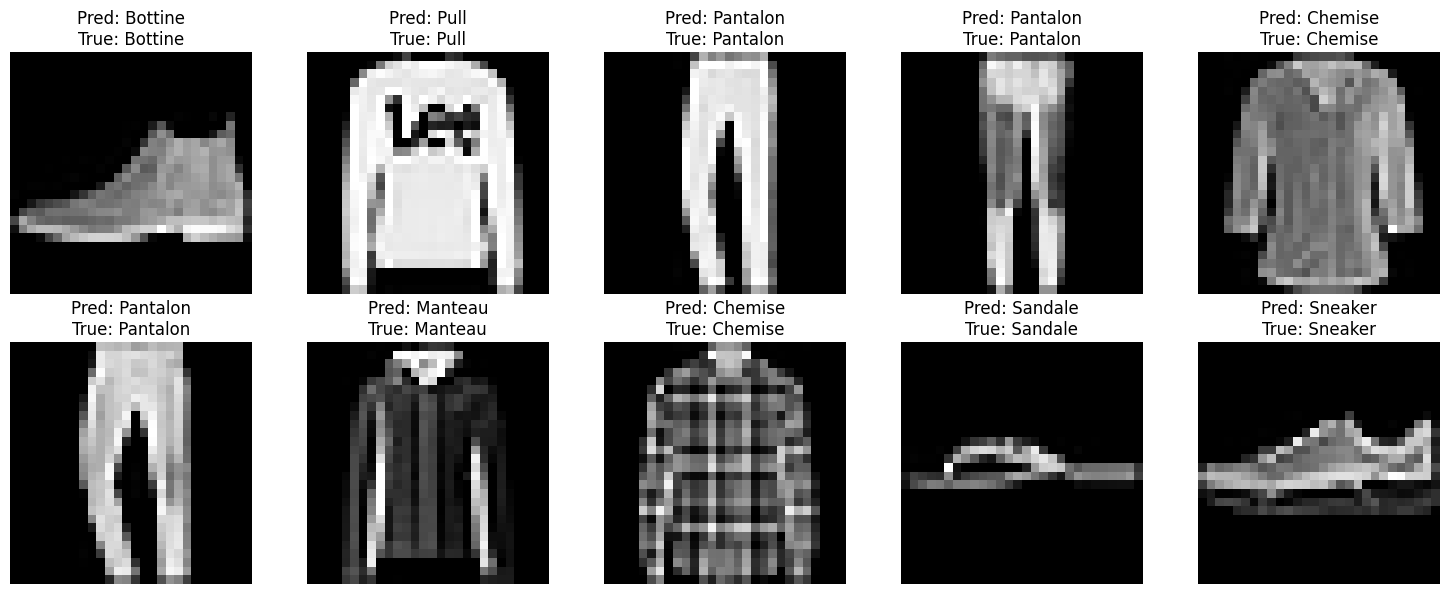

In [11]:
prediction = model.predict(X_test_flat[:10])
predicted_classes = np.argmax(prediction, axis=1)
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

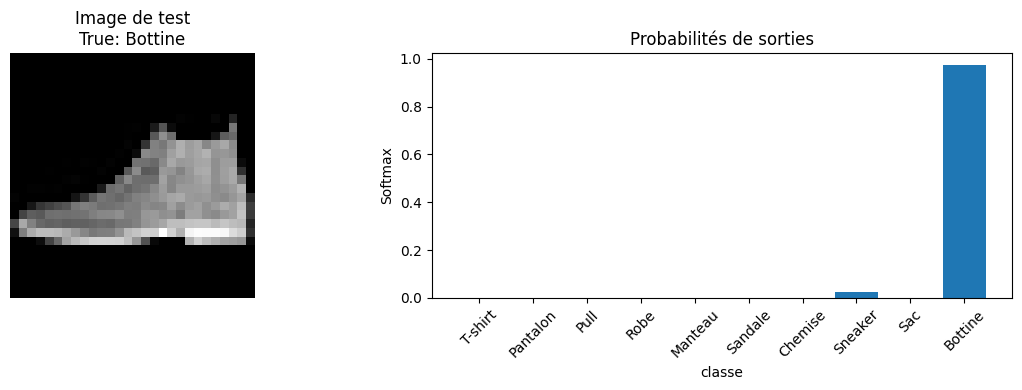

In [ ]:
idx = 0
sample_prediction = prediction[idx]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(X_test[idx], cmap='gray')
ax1.set_title(f"Image de test\nTrue: {class_names[y_test[idx]]}")
ax1.axis('off')

ax2.bar(range(10), sample_prediction)
ax2.set_xlabel("classe")
ax2.set_ylabel("Softmax")
ax2.set_title("Probabilités de sorties")
ax2.set_xticks(range(10))
ax2.set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

In [15]:
for i, prob in enumerate(sample_prediction):
    print(f"{class_names[i]}: {prob*100:2f}%")

T-shirt: 0.000025%
Pantalon: 0.000001%
Pull: 0.000193%
Robe: 0.000125%
Manteau: 0.000354%
Sandale: 0.022051%
Chemise: 0.000342%
Sneaker: 2.513008%
Sac: 0.000161%
Bottine: 97.463745%
